In [22]:
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder,
    FunctionTransformer,
    MinMaxScaler
)
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.utils.class_weight import compute_class_weight
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

In [23]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [24]:
TRAIN_DATA_PATH = Path("../data/processed/nsl_kdd_selected_features_train.csv")
TEST_DATA_PATH = Path("../data/processed/nsl_kdd_selected_features_test.csv")

In [25]:
train_df = pd.read_csv(TRAIN_DATA_PATH)
test_df = pd.read_csv(TEST_DATA_PATH)

In [26]:
train_df.head()

,duration,src_bytes,dst_bytes,count,srv_count,same_srv_rate,diff_srv_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,serror_rate,srv_serror_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,logged_in,hot,is_guest_login,protocol_type,service,flag,total_bytes,byte_ratio,inbound_outbound_ratio,connection_intensity_ratio,combined_error_rate,service_rarity,command_density,login_anomaly_score,is_attack_binary,is_attack_multiclass
0,0.0,491,0,2,2,1.00,0.00,150,25,0.17,0.03,0.17,0.00,0.0,0.0,0.00,0.00,0.05,0,0,0,tcp,ftp_data,SF,491,491.000000,0.000000,0.666667,0.0,18.363411,0.0,0.0,0,normal
1,0.0,146,0,13,1,0.08,0.15,255,1,0.00,0.60,0.88,0.00,0.0,0.0,0.00,0.00,0.00,0,0,0,udp,other,SF,146,146.000000,0.000000,6.500000,0.0,28.899518,0.0,0.0,0,normal
2,0.0,0,0,123,6,0.05,0.07,255,26,0.10,0.05,0.00,0.00,1.0,1.0,1.00,1.00,0.00,0,0,0,tcp,private,S0,0,0.000000,0.000000,17.571429,0.5,5.764563,0.0,0.0,1,dos
3,0.0,232,8153,5,5,1.00,0.00,30,255,1.00,0.00,0.03,0.04,0.2,0.2,0.03,0.01,0.00,1,0,0,tcp,http,SF,8385,0.028452,34.991416,0.833333,0.1,3.122936,0.0,0.0,0,normal
4,0.0,199,420,30,32,1.00,0.00,255,255,1.00,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,1,0,0,tcp,http,SF,619,0.472684,2.100000,0.909091,0.0,3.122936,0.0,0.0,0,normal


In [27]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 34 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  float64
 1   src_bytes                    125973 non-null  int64  
 2   dst_bytes                    125973 non-null  int64  
 3   count                        125973 non-null  int64  
 4   srv_count                    125973 non-null  int64  
 5   same_srv_rate                125973 non-null  float64
 6   diff_srv_rate                125973 non-null  float64
 7   dst_host_count               125973 non-null  int64  
 8   dst_host_srv_count           125973 non-null  int64  
 9   dst_host_same_srv_rate       125973 non-null  float64
 10  dst_host_diff_srv_rate       125973 non-null  float64
 11  dst_host_same_src_port_rate  125973 non-null  float64
 12  dst_host_srv_diff_host_rate  125973 non-null  float64
 13 

In [28]:
test_df.head()

,duration,src_bytes,dst_bytes,total_bytes,byte_ratio,inbound_outbound_ratio,count,srv_count,diff_srv_rate,same_srv_rate,connection_intensity_ratio,dst_host_count,dst_host_srv_count,dst_host_diff_srv_rate,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,serror_rate,srv_serror_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,combined_error_rate,logged_in,hot,num_failed_logins,root_shell,is_guest_login,protocol_type,service,flag,login_anomaly_score,privileged_ratio,service_rarity,command_density,is_attack_binary,is_attack_multiclass
0,0.0,0,0,0,0.0,0.0,229,10,0.06,0.04,20.818182,255,10,0.06,0.04,0.00,0.00,0.0,0.00,0.0,0.0,1.00,0.500,0,0,0,0,0,tcp,private,REJ,0.0,0.0,4.722245,0.0,1,dos
1,0.0,0,0,0,0.0,0.0,136,1,0.06,0.01,68.000000,255,1,0.06,0.00,0.00,0.00,0.0,0.00,0.0,0.0,1.00,0.500,0,0,0,0,0,tcp,private,REJ,0.0,0.0,4.722245,0.0,1,dos
2,2.0,12983,0,12983,12983.0,0.0,1,1,0.00,1.00,0.500000,134,86,0.04,0.61,0.61,0.02,0.0,0.00,0.0,0.0,0.00,0.000,0,0,0,0,0,tcp,ftp_data,SF,0.0,0.0,26.491187,0.0,0,normal
3,0.0,20,0,20,20.0,0.0,1,65,0.00,1.00,0.015152,3,57,0.00,1.00,1.00,0.28,0.0,0.00,0.0,0.0,0.00,0.000,0,0,0,0,0,icmp,eco_i,SF,0.0,0.0,86.045802,0.0,1,probe
4,1.0,0,15,15,0.0,15.0,1,8,0.00,1.00,0.111111,29,86,0.17,0.31,0.03,0.02,0.0,0.12,0.0,0.0,0.83,0.405,0,0,0,0,0,tcp,telnet,RSTO,0.0,0.0,13.864699,0.0,1,probe


In [29]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  float64
 1   src_bytes                    22544 non-null  int64  
 2   dst_bytes                    22544 non-null  int64  
 3   total_bytes                  22544 non-null  int64  
 4   byte_ratio                   22544 non-null  float64
 5   inbound_outbound_ratio       22544 non-null  float64
 6   count                        22544 non-null  int64  
 7   srv_count                    22544 non-null  int64  
 8   diff_srv_rate                22544 non-null  float64
 9   same_srv_rate                22544 non-null  float64
 10  connection_intensity_ratio   22544 non-null  float64
 11  dst_host_count               22544 non-null  int64  
 12  dst_host_srv_count           22544 non-null  int64  
 13  dst_host_diff_sr

In [30]:
target_cols = ['is_attack_binary', 'is_attack_multiclass']

In [31]:
train_df['is_attack_multiclass'].value_counts()

is_attack_multiclass
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

In [32]:
X_train_full = train_df.drop(columns=target_cols)
X_test_full = test_df.drop(columns=target_cols)

In [33]:
yb_train_full = train_df['is_attack_binary']
yb_test_full = test_df['is_attack_binary']

In [34]:
le_multi = LabelEncoder()
ym_train_full = le_multi.fit_transform(train_df['is_attack_multiclass'])
ym_test_full = le_multi.transform(test_df['is_attack_multiclass'])

In [35]:
print(dict(zip(le_multi.classes_, range(len(le_multi.classes_)))))

{'dos': 0, 'normal': 1, 'probe': 2, 'r2l': 3, 'u2r': 4}


In [36]:
num_features = X_train_full.select_dtypes(include=[np.number]).columns.tolist()

In [37]:
cat_features = X_train_full.select_dtypes(include=['object']).columns

In [38]:
cat_features,len(cat_features)

(Index(['protocol_type', 'service', 'flag'], dtype='object'), 3)

In [39]:
num_features,len(num_features)

(['duration',
  'src_bytes',
  'dst_bytes',
  'count',
  'srv_count',
  'same_srv_rate',
  'diff_srv_rate',
  'dst_host_count',
  'dst_host_srv_count',
  'dst_host_same_srv_rate',
  'dst_host_diff_srv_rate',
  'dst_host_same_src_port_rate',
  'dst_host_srv_diff_host_rate',
  'serror_rate',
  'srv_serror_rate',
  'dst_host_serror_rate',
  'dst_host_srv_serror_rate',
  'dst_host_rerror_rate',
  'logged_in',
  'hot',
  'is_guest_login',
  'total_bytes',
  'byte_ratio',
  'inbound_outbound_ratio',
  'connection_intensity_ratio',
  'combined_error_rate',
  'service_rarity',
  'command_density',
  'login_anomaly_score'],
 29)

In [40]:
# 3. PREPROCESSING PIPELINE SETUP
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features)
    ],
    remainder='drop'
)

In [41]:
# Fit preprocessor and transform data
X_train_processed = preprocessor.fit_transform(X_train_full)
X_test_processed = preprocessor.transform(X_test_full)

In [42]:
# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'recall_macro': 'recall_macro'
}

In [43]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [44]:
# 4. MODEL DEFINITIONS AND UTILITY FUNCTIONS
# Scoring function
def test_set_scorer(model_name, model, X_train, y_train, X_test, y_test):
    # Fit on training set
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Compute metrics
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted'),
        'recall_macro': recall_score(y_test, y_pred, average='macro')
    }

In [45]:
# Binary classification models
model_dict_binary = {
    'logistic_regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'random_forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'naive_bayes': GaussianNB(),
    'knn': KNeighborsClassifier(n_neighbors=5, weights='distance', metric='minkowski', n_jobs=-1),
    'xgboost': XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, use_label_encoder=False),
}

# Multiclass classification models
model_dict_multi = {
    'logistic_regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1, multi_class='auto'),
    'random_forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'naive_bayes': GaussianNB(),
    'knn': KNeighborsClassifier(n_neighbors=5, weights='distance', metric='minkowski', n_jobs=-1),
    'xgboost': XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', 
                            num_class=len(np.unique(ym_train_full)), random_state=42, use_label_encoder=False),
}

In [48]:
# Binary classification test set comparison
binary_results_test = []
for name, model in model_dict_binary.items():
    print(f"Evaluating Binary Model on Test Set: {name}")
    result = test_set_scorer(name, model, X_train_processed, yb_train_full, X_test_processed, yb_test_full)
    binary_results_test.append(result)

binary_df_test = pd.DataFrame(binary_results_test).sort_values('recall_macro', ascending=False)
print("\nBinary Classification Comparison (Test Set) ")
binary_df_test

Evaluating Binary Model on Test Set: logistic_regression
Evaluating Binary Model on Test Set: random_forest
Evaluating Binary Model on Test Set: naive_bayes
Evaluating Binary Model on Test Set: knn
Evaluating Binary Model on Test Set: xgboost

Binary Classification Comparison (Test Set) 


,model,accuracy,f1_macro,f1_weighted,recall_macro
4,xgboost,0.793426,0.793036,0.791791,0.815072
3,knn,0.779498,0.779406,0.778784,0.797614
1,random_forest,0.771159,0.770123,0.767987,0.795713
0,logistic_regression,0.755545,0.755122,0.753712,0.776186
2,naive_bayes,0.593062,0.561817,0.545613,0.642362


In [49]:
# Multiclass classification test set comparison
multi_results_test = []
for name, model in model_dict_multi.items():
    print(f"Evaluating Multiclass Model on Test Set: {name}")
    result = test_set_scorer(name, model, X_train_processed, ym_train_full, X_test_processed, ym_test_full)
    multi_results_test.append(result)

multi_df_test = pd.DataFrame(multi_results_test).sort_values('recall_macro', ascending=False).reset_index(drop=True)
print("\nMulticlass Classification Comparison (Test Set) ")
multi_df_test


Evaluating Multiclass Model on Test Set: logistic_regression
Evaluating Multiclass Model on Test Set: random_forest
Evaluating Multiclass Model on Test Set: naive_bayes
Evaluating Multiclass Model on Test Set: knn
Evaluating Multiclass Model on Test Set: xgboost

Multiclass Classification Comparison (Test Set) 


,model,accuracy,f1_macro,f1_weighted,recall_macro
0,xgboost,0.779542,0.530359,0.742793,0.515665
1,knn,0.759626,0.496198,0.716516,0.505715
2,random_forest,0.757807,0.490152,0.712374,0.486682
3,logistic_regression,0.751242,0.482108,0.704719,0.485394
4,naive_bayes,0.462961,0.365748,0.484882,0.376582


In [51]:
# Merge results for side-by-side comparison
comparison_df_test = binary_df_test.merge(multi_df_test, on='model', suffixes=('_binary', '_multiclass'))
print("\nBinary vs Multiclass Comparison (Test Set) ")
comparison_df_test


Binary vs Multiclass Comparison (Test Set) 


,model,accuracy_binary,f1_macro_binary,f1_weighted_binary,recall_macro_binary,accuracy_multiclass,f1_macro_multiclass,f1_weighted_multiclass,recall_macro_multiclass
0,xgboost,0.793426,0.793036,0.791791,0.815072,0.779542,0.530359,0.742793,0.515665
1,knn,0.779498,0.779406,0.778784,0.797614,0.759626,0.496198,0.716516,0.505715
2,random_forest,0.771159,0.770123,0.767987,0.795713,0.757807,0.490152,0.712374,0.486682
3,logistic_regression,0.755545,0.755122,0.753712,0.776186,0.751242,0.482108,0.704719,0.485394
4,naive_bayes,0.593062,0.561817,0.545613,0.642362,0.462961,0.365748,0.484882,0.376582


In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features)
    ],
    remainder='drop'
)

# Fit on train, transform both train and test
X_train_processed = preprocessor.fit_transform(X_train_full)
X_test_processed = preprocessor.transform(X_test_full)

 Binary Classification Reports with Confusion Matrix Charts (Test Set) 

Processing model: logistic_regression
Model: logistic_regression
Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.93      0.77      9711
           1       0.92      0.63      0.74     12833

    accuracy                           0.76     22544
   macro avg       0.78      0.78      0.76     22544
weighted avg       0.80      0.76      0.75     22544



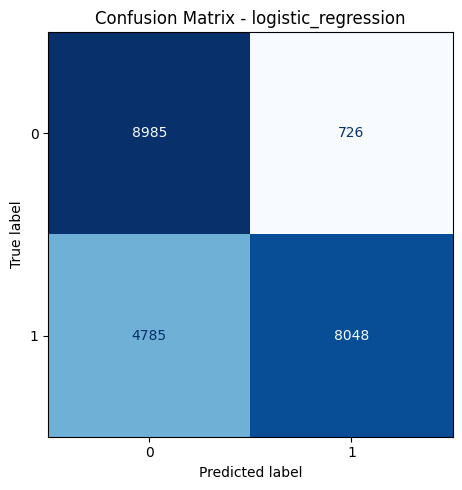

Processing model: random_forest
Model: random_forest
Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.97      0.79      9711
           1       0.97      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544



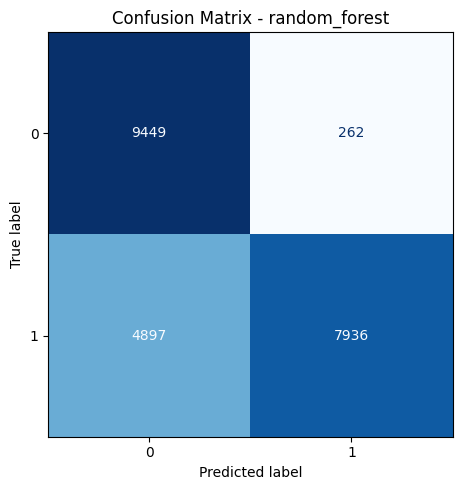

Processing model: naive_bayes
Model: naive_bayes
Classification Report:

              precision    recall  f1-score   support

           0       0.51      1.00      0.68      9711
           1       1.00      0.29      0.44     12833

    accuracy                           0.59     22544
   macro avg       0.75      0.64      0.56     22544
weighted avg       0.79      0.59      0.55     22544



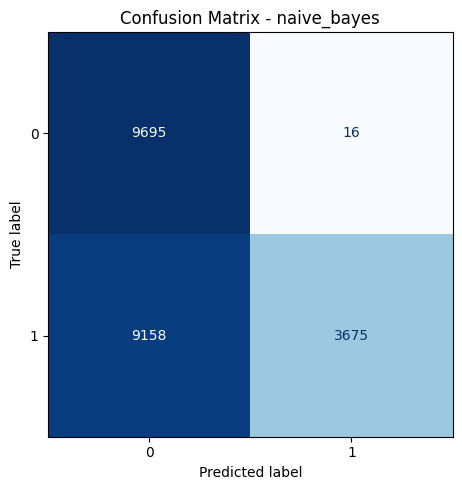

Processing model: knn
Model: knn
Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.93      0.78      9711
           1       0.92      0.67      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.80      0.80      0.78     22544
weighted avg       0.82      0.78      0.78     22544



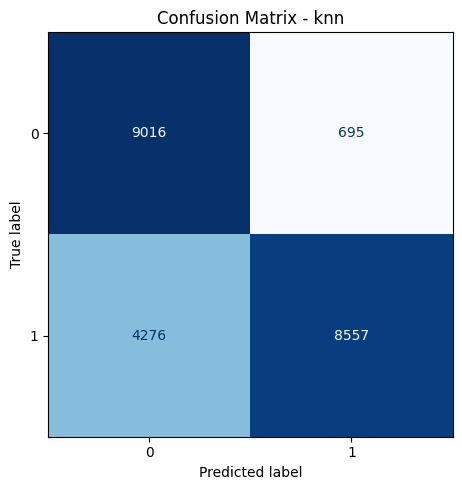

Processing model: xgboost
Model: xgboost
Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.97      0.80      9711
           1       0.97      0.66      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.83      0.82      0.79     22544
weighted avg       0.85      0.79      0.79     22544



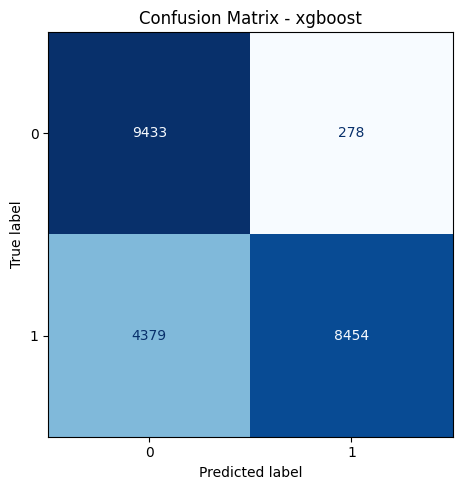

In [53]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

binary_classification_reports = {}

print(" Binary Classification Reports with Confusion Matrix Charts (Test Set) \n")

for name, model in model_dict_binary.items():
    print(f"Processing model: {name}")
    
    # Fit model on TRAIN set
    model.fit(X_train_processed, yb_train_full)
    
    # Predict on TEST set
    y_pred_test = model.predict(X_test_processed)
    
    # Classification report
    report = classification_report(yb_test_full, y_pred_test, output_dict=True)
    binary_classification_reports[name] = report
    
    # Confusion matrix
    cm = confusion_matrix(yb_test_full, y_pred_test)
    
    # Print classification report
    print(f"Model: {name}")
    print("Classification Report:\n")
    print(classification_report(yb_test_full, y_pred_test))
    
    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(5, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[0, 1]  # adjust if your labels differ
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()
    

### Applying the best model

In [53]:
# 1. Define BASELINE XGBoost classifier (binary)
xgb_baseline_bin = XGBClassifier(
    objective='binary:logistic',  # binary classification
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',  # binary metric
    random_state=42,
    n_jobs=-1
)

In [54]:
# 2. Create pipeline (keep preprocessor if needed)
pipeline_xgb_bin = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_baseline_bin)
])

In [55]:
# 3. Stratified Cross-Validation (macro F1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline_xgb_bin,
    X_train_full,
    yb_train_full,
    cv=cv,
    scoring='f1_macro'  # for binary, macro F1 is still valid
)

In [56]:
print("Cross-Validation Macro F1 Scores:", cv_scores)
print("Mean CV Macro F1 Score:", cv_scores.mean())

Cross-Validation Macro F1 Scores: [0.99924225 0.99904282 0.99872367 0.99912251 0.99908266]
Mean CV Macro F1 Score: 0.9990427834155164


In [57]:
# 4. Train on full training data
pipeline_xgb_bin.fit(X_train_full, yb_train_full)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
# 5. Evaluate on test set
y_test_pred = pipeline_xgb_bin.predict(X_test_full)

print("Final Binary XGBoost Classification Report")
print(classification_report(yb_test_full, y_test_pred))

Final Binary XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.68      0.97      0.80      9711
           1       0.97      0.66      0.79     12833

    accuracy                           0.79     22544
   macro avg       0.83      0.82      0.79     22544
weighted avg       0.85      0.79      0.79     22544



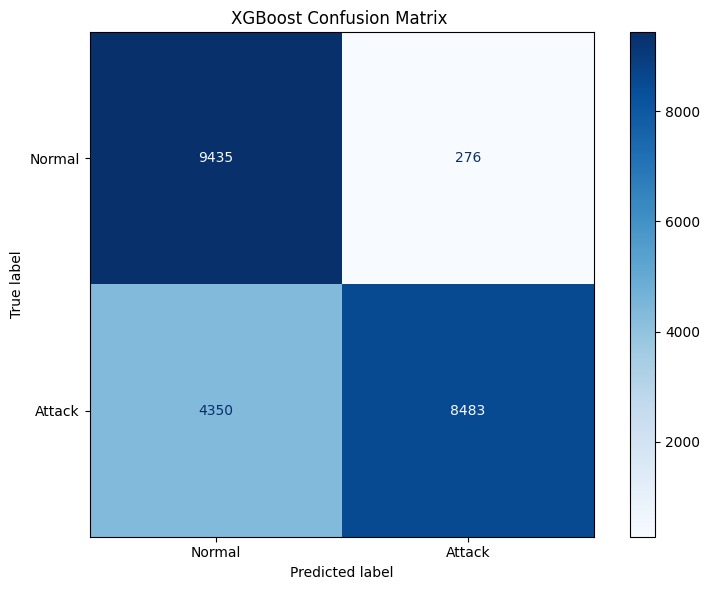

In [62]:
# 9. CONFUSION MATRIX
cm = confusion_matrix(yb_test_full, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Normal', 'Attack']
)

disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f"XGBoost Confusion Matrix ")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report

preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)  # <- dense
])

# 2. Pipeline with GaussianNB
pipeline_nb_bin = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB(var_smoothing=1e-8))
])

# 3. Stratified Cross-Validation (macro F1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline_nb_bin,
    X_train_full,
    yb_train_full,
    cv=cv,
    scoring='f1_macro'
)

print("Cross-Validation Macro F1 Scores:", cv_scores)
print("Mean CV Macro F1 Score:", cv_scores.mean())

# 4. Train on full training data
pipeline_nb_bin.fit(X_train_full, yb_train_full)

# 5. Evaluate on test set
y_test_pred = pipeline_nb_bin.predict(X_test_full)

print("Final Binary Gaussian Naive Bayes Classification Report")
print(classification_report(yb_test_full, y_test_pred))


Cross-Validation Macro F1 Scores: [0.8687401  0.8709229  0.88084693 0.87295926 0.87242786]
Mean CV Macro F1 Score: 0.8731794097916818

--- Final Binary Gaussian Naive Bayes Classification Report ---
              precision    recall  f1-score   support

           0       0.58      0.94      0.72      9711
           1       0.91      0.49      0.64     12833

    accuracy                           0.69     22544
   macro avg       0.75      0.72      0.68     22544
weighted avg       0.77      0.69      0.68     22544



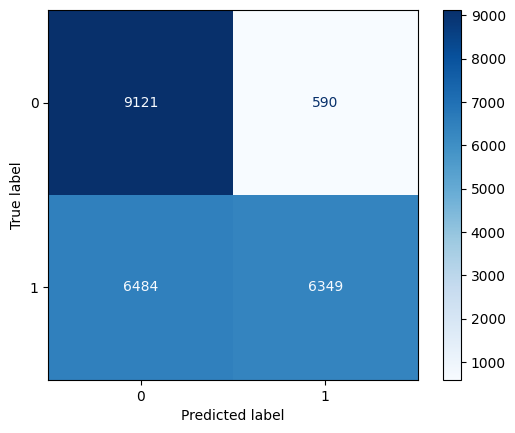

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(yb_test_full, y_test_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline_nb_bin.classes_)
disp.plot(cmap='Blues')  # nice blue color


In [51]:
from sklearn.ensemble import (
    StackingClassifier, 
    VotingClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import classification_report, f1_score, accuracy_score, recall_score
import numpy as np
import pandas as pd
import warnings

In [52]:
### Bagging model

In [ ]:
# Bagging: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

In [54]:
### Boosting model

In [ ]:
# Boosting: XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

# Boosting: LightGBM
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgbm_model)
])

# Boosting: Gradient Boosting
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    n_jobs=-1
)

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('classifier', knn_model)
])

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', gb_model)
])

In [56]:
### Stacking model

In [57]:
stacking_model = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('knn', knn_model),
        ('rf', rf_model)
    ],
    final_estimator=LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ),
    cv=5,
    n_jobs=-1
)

stacking_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', stacking_model)
])

In [58]:
### Voting model

In [59]:
voting_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgbm', lgbm_model),
        ('knn', knn_model),
        ('rf', rf_model),
    ],
    voting='soft',
    weights=[3, 2, 2, 1],
    n_jobs=-1
)

voting_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', voting_model)
])

In [60]:
### Evaluation function

In [ ]:
# Prepare data
X_train = X_train_full
X_test = X_test_full
y_train = yb_train_full
y_test = yb_test_full

# Ensemble models only
ensemble_models = [
    (rf_pipeline, 'Bagging (Random Forest)'),
    (xgb_pipeline, 'Boosting (XGBoost)'),
    (lgbm_pipeline, 'Boosting (LightGBM)'),
    (gb_pipeline, 'Boosting (Gradient Boosting)'),
    (stacking_pipeline, 'Stacking Classifier'),
    (voting_pipeline, 'Voting Classifier')
]

# Store results
results = []

# Evaluate ensemble models
for model, name in ensemble_models:
    print(f"Evaluating {name}...")
    
    # Fit the model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    recall_macro = recall_score(y_test, y_pred, average='macro')
    
    # Cross-validation F1-macro
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    
    # Append results
    results.append({
        'model': name,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'recall_macro': recall_macro,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std()
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False).reset_index(drop=True)

# Display
print("ENSEMBLE MODEL PERFORMANCE COMPARISON")
print(results_df.to_string(index=False))

Evaluating Bagging (Random Forest)...
Evaluating Boosting (XGBoost)...
Evaluating Boosting (LightGBM)...
[LightGBM] [Info] Number of positive: 58630, number of negative: 67343
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012536 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4606
[LightGBM] [Info] Number of data points in the train set: 125973, number of used features: 104
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.465417 -> initscore=-0.138552
[LightGBM] [Info] Start training from score -0.138552
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl


CLASSIFICATION REPORT  Bagging (Random Forest)

              precision    recall  f1-score   support

           0       0.66      0.97      0.78      9711
           1       0.97      0.61      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.77     22544



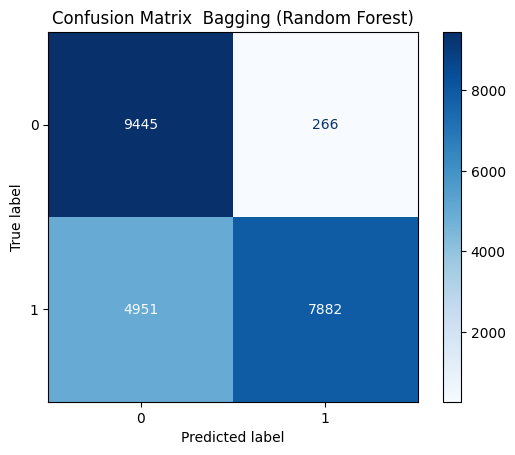


CLASSIFICATION REPORT  Boosting (XGBoost)

              precision    recall  f1-score   support

           0       0.69      0.97      0.80      9711
           1       0.97      0.66      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.79     22544



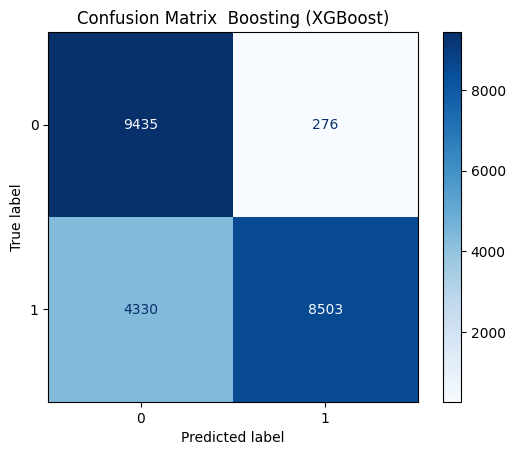


CLASSIFICATION REPORT  Boosting (LightGBM)

              precision    recall  f1-score   support

           0       0.67      0.97      0.79      9711
           1       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544



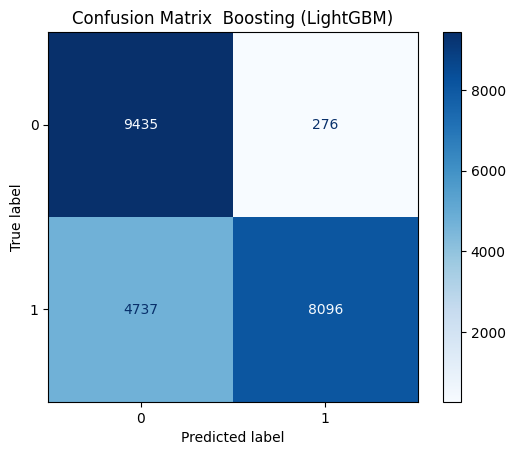


CLASSIFICATION REPORT  Boosting (Gradient Boosting)

              precision    recall  f1-score   support

           0       0.71      0.97      0.82      9711
           1       0.97      0.70      0.82     12833

    accuracy                           0.82     22544
   macro avg       0.84      0.84      0.82     22544
weighted avg       0.86      0.82      0.82     22544



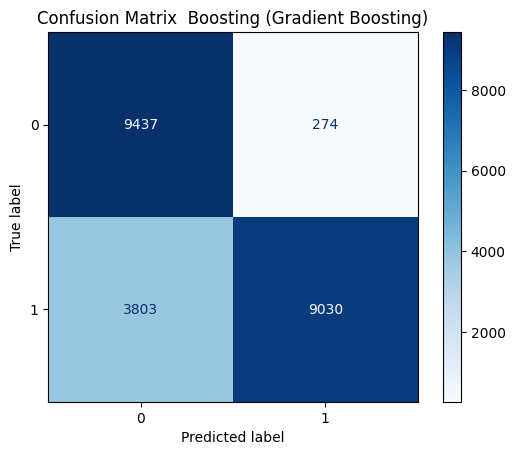


CLASSIFICATION REPORT  Stacking Classifier

              precision    recall  f1-score   support

           0       0.68      0.97      0.80      9711
           1       0.97      0.66      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.79     22544
weighted avg       0.85      0.80      0.79     22544



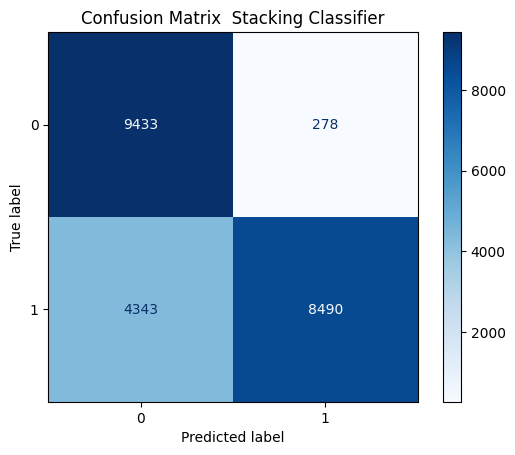


CLASSIFICATION REPORT  Voting Classifier

              precision    recall  f1-score   support

           0       0.68      0.97      0.80      9711
           1       0.97      0.65      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544



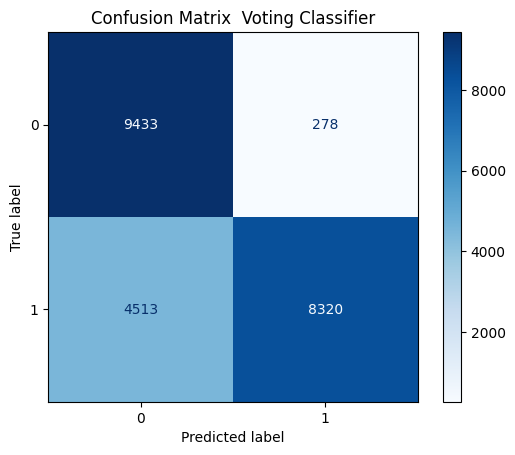

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict & display reports for all ensemble models

# 1️. Bagging (Random Forest)
y_pred_rf = rf_pipeline.predict(X_test)
print("CLASSIFICATION REPORT  Bagging (Random Forest)")
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap="Blues")
plt.title("Confusion Matrix  Bagging (Random Forest)")
plt.show()

# 2️. Boosting (XGBoost)
y_pred_xgb = xgb_pipeline.predict(X_test)
print("\nCLASSIFICATION REPORT  Boosting (XGBoost)\n")
print(classification_report(y_test, y_pred_xgb))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot(cmap="Blues")
plt.title("Confusion Matrix  Boosting (XGBoost)")
plt.show()

# 3️. Boosting (LightGBM)
y_pred_lgbm = lgbm_pipeline.predict(X_test)
print("CLASSIFICATION REPORT  Boosting (LightGBM)")
print(classification_report(y_test, y_pred_lgbm))
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
disp_lgbm = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm)
disp_lgbm.plot(cmap="Blues")
plt.title("Confusion Matrix  Boosting (LightGBM)")
plt.show()

# 4️. Boosting (Gradient Boosting)
y_pred_gb = gb_pipeline.predict(X_test)
print("CLASSIFICATION REPORT  Boosting (Gradient Boosting)\n")
print(classification_report(y_test, y_pred_gb))
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb)
disp_gb.plot(cmap="Blues")
plt.title("Confusion Matrix  Boosting (Gradient Boosting)")
plt.show()

# 5️. Stacking Classifier
y_pred_stack = stacking_pipeline.predict(X_test)
print("CLASSIFICATION REPORT  Stacking Classifier\n")
print(classification_report(y_test, y_pred_stack))
cm_stack = confusion_matrix(y_test, y_pred_stack)
disp_stack = ConfusionMatrixDisplay(confusion_matrix=cm_stack)
disp_stack.plot(cmap="Blues")
plt.title("Confusion Matrix  Stacking Classifier")
plt.show()

# 6️. Voting Classifier
y_pred_vote = voting_pipeline.predict(X_test)
print("CLASSIFICATION REPORT  Voting Classifier\n")
print(classification_report(y_test, y_pred_vote))
cm_vote = confusion_matrix(y_test, y_pred_vote)
disp_vote = ConfusionMatrixDisplay(confusion_matrix=cm_vote)
disp_vote.plot(cmap="Blues")
plt.title("Confusion Matrix  Voting Classifier")
plt.show()

### Getting Score with Smote + HyperTunin + Threshold

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
    ]
)

In [33]:
from sklearn.model_selection import train_test_split
# K is number of features to keep
K = 70

# Split data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    yb_train_full,
    test_size=0.15,
    stratify=yb_train_full,
    random_state=42
)

In [34]:
# Encode all the data
X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test_full)

In [35]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
# Pick the best features
selector = SelectKBest(mutual_info_classif, k=min(K, X_train_enc.shape[1]))
X_train_sel = selector.fit_transform(X_train_enc, y_train)
X_val_sel = selector.transform(X_val_enc)
X_test_sel = selector.transform(X_test_enc)

print(f"Before selection: {X_train_enc.shape}")
print(f"After selection: {X_train_sel.shape}")

Before selection: (107077, 112)
After selection: (107077, 70)


In [36]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import BorderlineSMOTE
# Make a pipeline with SMOTE and XGBoost
pipe = Pipeline(steps=[
    ("smote", BorderlineSMOTE(random_state=42)),
    ("xgb", XGBClassifier(random_state=42, n_jobs=-1))
])

In [37]:
# Hyperparameter tuning with random search
from scipy.stats import randint, uniform
# Parameters to try
params = {
    "xgb__n_estimators": randint(200, 1200),
    "xgb__max_depth": randint(3, 12),
    "xgb__learning_rate": uniform(0.01, 0.3),
    "xgb__min_child_weight": randint(1, 20),
    "xgb__subsample": uniform(0.6, 0.4),
    "xgb__colsample_bytree": uniform(0.6, 0.4),
    "xgb__gamma": uniform(0.0, 0.5),
    "xgb__reg_alpha": uniform(0.0, 1.0),
    "xgb__reg_lambda": uniform(0.5, 2.0),
}

In [38]:
# random search
search = RandomizedSearchCV(
    pipe, 
    params, 
    n_iter=40,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train_sel, y_train)

print(f"Best F1 score: {search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best F1 score: 0.9987
Best params:
  xgb__colsample_bytree: 0.821105986734196
  xgb__gamma: 0.28614623458541916
  xgb__learning_rate: 0.3040994751148137
  xgb__max_depth: 6
  xgb__min_child_weight: 1
  xgb__n_estimators: 455
  xgb__reg_alpha: 0.4852798742763157
  xgb__reg_lambda: 1.2453737341880986
  xgb__subsample: 0.7578765867237889


In [39]:
# Train final model with best parameters

# Balance the training data
sm = BorderlineSMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_sel, y_train)
print(f"Classes after balancing: {np.bincount(y_train_bal)}")

Classes after balancing: [57242 57242]


In [40]:
# Get best parameters
best_params = {k.replace('xgb__', ''): v for k, v in search.best_params_.items()}

In [41]:
import xgboost as xgb
# Setup for XGBoost
dtrain = xgb.DMatrix(X_train_bal, label=y_train_bal)
dval = xgb.DMatrix(X_val_sel, label=y_val)

In [42]:
# Model settings
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'learning_rate': best_params['learning_rate'],
    'max_depth': int(best_params['max_depth']),
    'min_child_weight': best_params['min_child_weight'],
    'subsample': best_params['subsample'],
    'colsample_bytree': best_params['colsample_bytree'],
    'gamma': best_params['gamma'],
    'reg_alpha': best_params['reg_alpha'],
    'reg_lambda': best_params['reg_lambda'],
    'seed': 42
}

In [43]:
# Train with early stopping
model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=int(best_params['n_estimators']),
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=50,
    verbose_eval=25
)

[0]	train-logloss:0.44704	val-logloss:0.44248
[25]	train-logloss:0.00765	val-logloss:0.00635
[50]	train-logloss:0.00232	val-logloss:0.00325
[75]	train-logloss:0.00131	val-logloss:0.00283
[100]	train-logloss:0.00107	val-logloss:0.00279
[125]	train-logloss:0.00100	val-logloss:0.00280
[150]	train-logloss:0.00097	val-logloss:0.00276
[175]	train-logloss:0.00094	val-logloss:0.00279
[200]	train-logloss:0.00093	val-logloss:0.00279


In [44]:
# Step 5: Find best threshold
val_probs = model.predict(dval)

In [ ]:
# Threshold tuning (Validation set)
from sklearn.metrics import precision_score, recall_score, f1_score
# Threshold search space
thresholds = np.linspace(0.05, 0.6, 200)
MIN_PRECISION = 0.80

results = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)

    prec = precision_score(y_val, preds, zero_division=0)
    rec  = recall_score(y_val, preds, zero_division=0)
    f1   = f1_score(y_val, preds, zero_division=0)

    if prec >= MIN_PRECISION:
        results.append((t, prec, rec, f1))

# Select threshold with MAX recall (security objective)
best_t, best_p, best_r, best_f1 = max(results, key=lambda x: x[2])

print(
    f"Chosen threshold (Recall-optimized): {best_t:.3f} | "
    f"Precision: {best_p:.4f} | Recall: {best_r:.4f} | F1: {best_f1:.4f}"
)



Chosen threshold (Recall-optimized): 0.050 | Precision: 0.9956 | Recall: 0.9998 | F1: 0.9977


 === FINAL EVAL (Hyper-tuned XGBoost) ===
              precision    recall  f1-score   support

           0     0.7955    0.9606    0.8703      9711
           1     0.9646    0.8131    0.8824     12833

    accuracy                         0.8766     22544
   macro avg     0.8800    0.8868    0.8763     22544
weighted avg     0.8918    0.8766    0.8772     22544

Accuracy: 0.8766 | Precision: 0.9646 | Recall: 0.8131 | F1: 0.8824


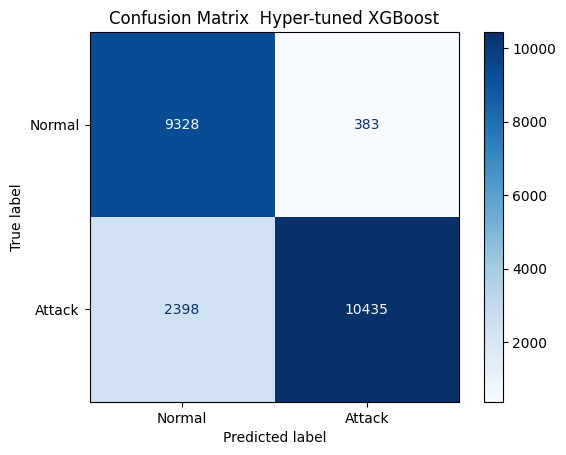

In [ ]:
# Evaluate on test set

from sklearn.metrics import (
    classification_report,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

dtest = xgb.DMatrix(X_test_sel)
probs_test = model.predict(dtest)

y_test_pred = (probs_test >= best_t).astype(int)

print(" FINAL EVAL (Hyper-tuned XGBoost) ")
print(classification_report(yb_test_full, y_test_pred, digits=4))

precision, recall, f1, _ = precision_recall_fscore_support(
    yb_test_full,
    y_test_pred,
    average="binary"
)

acc = (y_test_pred == yb_test_full).mean()

print(
    f"Accuracy: {acc:.4f} | "
    f"Precision: {precision:.4f} | "
    f"Recall: {recall:.4f} | "
    f"F1: {f1:.4f}"
)

# Confusion Matrix

cm = confusion_matrix(yb_test_full, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix  Hyper-tuned XGBoost")
plt.show()


In [17]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


train_normal = train_df[train_df['is_attack_binary'] == 0]

X_train_normal = train_normal.drop(
    columns=['is_attack_binary', 'is_attack_multiclass']
)

X_test = test_df.drop(
    columns=['is_attack_binary', 'is_attack_multiclass']
)

y_test = test_df['is_attack_binary']

In [84]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


train_normal = train_df[train_df['is_attack_binary'] == 0]

X_train_normal = train_normal.drop(
    columns=['is_attack_binary', 'is_attack_multiclass']
)

X_test = test_df.drop(
    columns=['is_attack_binary', 'is_attack_multiclass']
)

y_test = test_df['is_attack_binary']

In [85]:
num_features = X_train_normal.select_dtypes(include=['int64','float64']).columns
cat_features = X_train_normal.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
    ]
)

X_train_proc = preprocessor.fit_transform(X_train_normal)
X_test_proc = preprocessor.transform(X_test)

input_dim = X_train_proc.shape[1]


In [86]:
def build_autoencoder(input_dim,
                      hidden_1=128,
                      hidden_2=64,
                      bottleneck=16,
                      lr=0.001):

    input_layer = Input(shape=(input_dim,))

    # Encoder
    x = Dense(hidden_1, activation='relu')(input_layer)
    x = Dense(hidden_2, activation='relu')(x)
    bottleneck_layer = Dense(bottleneck, activation='relu')(x)

    # Decoder
    x = Dense(hidden_2, activation='relu')(bottleneck_layer)
    x = Dense(hidden_1, activation='relu')(x)

    output_layer = Dense(input_dim, activation='linear')(x)

    model = Model(input_layer, output_layer)
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse'
    )

    return model


In [87]:
param_grid = [
    {'hidden_1': 128, 'hidden_2': 64, 'bottleneck': 16, 'lr': 1e-3},
    {'hidden_1': 128, 'hidden_2': 64, 'bottleneck': 32, 'lr': 1e-3},
    {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 16, 'lr': 1e-3},
    {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 32, 'lr': 1e-4},
]

In [88]:
best_model = None
best_val_loss = np.inf
best_params = None

for params in param_grid:
    print("\nTraining with params:", params)

    model = build_autoencoder(
        input_dim=input_dim,
        hidden_1=params['hidden_1'],
        hidden_2=params['hidden_2'],
        bottleneck=params['bottleneck'],
        lr=params['lr']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_proc,
        X_train_proc,
        epochs=50,
        batch_size=256,
        validation_split=0.15,
        shuffle=True,
        callbacks=[early_stop],
        verbose=0
    )

    val_loss = min(history.history['val_loss'])
    print("Validation Loss:", val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model
        best_params = params



Training with params: {'hidden_1': 128, 'hidden_2': 64, 'bottleneck': 16, 'lr': 0.001}
Validation Loss: 0.007317110430449247

Training with params: {'hidden_1': 128, 'hidden_2': 64, 'bottleneck': 32, 'lr': 0.001}
Validation Loss: 0.004851873032748699

Training with params: {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 16, 'lr': 0.001}
Validation Loss: 0.006399533245712519

Training with params: {'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 32, 'lr': 0.0001}
Validation Loss: 0.0025895473081618547


In [89]:
print("\nBEST PARAMETERS FOUND:")
print(best_params)


BEST PARAMETERS FOUND:
{'hidden_1': 256, 'hidden_2': 128, 'bottleneck': 32, 'lr': 0.0001}


In [90]:
# Reconstruction error on normal data
train_pred = best_model.predict(X_train_proc)
train_error = np.mean(
    np.square(X_train_proc - train_pred),
    axis=1
)

2105/2105 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


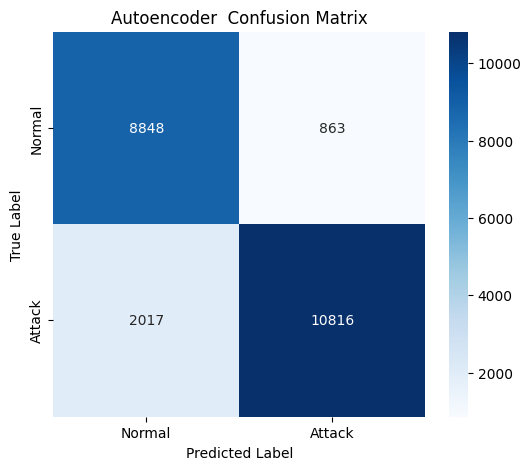

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Autoencoder  Confusion Matrix")
plt.show()


In [92]:
from sklearn.metrics import f1_score




2105/2105 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Best threshold: 0.003995712103713863
Best F1: 0.9206801046314818
Final Threshold Used: 0.003995712103713863

Autoencoder Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.91      0.88      0.89      9711
           1       0.91      0.93      0.92     12833

    accuracy                           0.91     22544
   macro avg       0.91      0.90      0.91     22544
weighted avg       0.91      0.91      0.91     22544



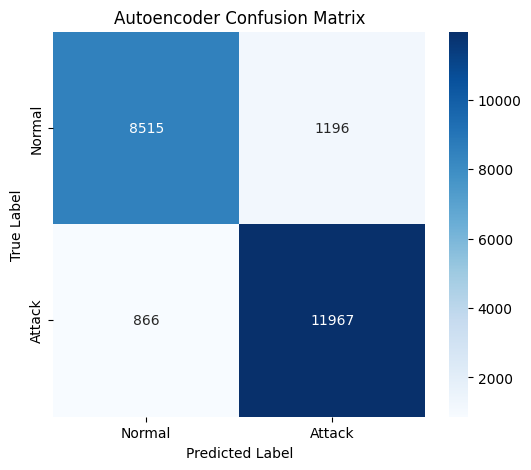

In [ ]:
# FINAL AUTOENCODER PREDICTION USING BEST THRESHOLD

from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

train_pred = best_model.predict(X_train_proc)
train_error = np.mean(
    np.square(X_train_proc - train_pred),
    axis=1
)

test_pred = best_model.predict(X_test_proc)
test_error = np.mean(
    np.square(X_test_proc - test_pred),
    axis=1
)

# USE BEST THRESHOLD FOUND ABOVE
best_f1 = 0
best_threshold = None

for p in range(90, 100):
    threshold = np.percentile(train_error, p)
    y_pred = (test_error > threshold).astype(int)

    f1 = f1_score(y_test, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

y_pred_ae = (test_error > best_threshold).astype(int)

print("Final Threshold Used:", best_threshold)
print("\nAutoencoder Classification Report (Test Set):\n")
print(classification_report(y_test, y_pred_ae))

cm = confusion_matrix(y_test, y_pred_ae)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Autoencoder Confusion Matrix")
plt.show()



ROC–AUC (Autoencoder): 0.9639547426188418


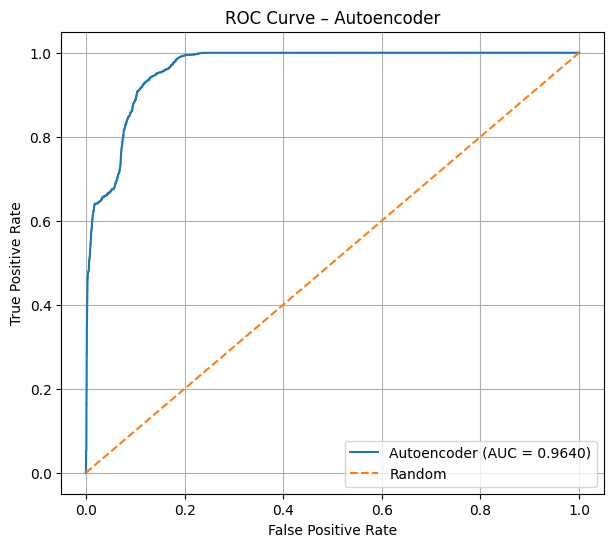

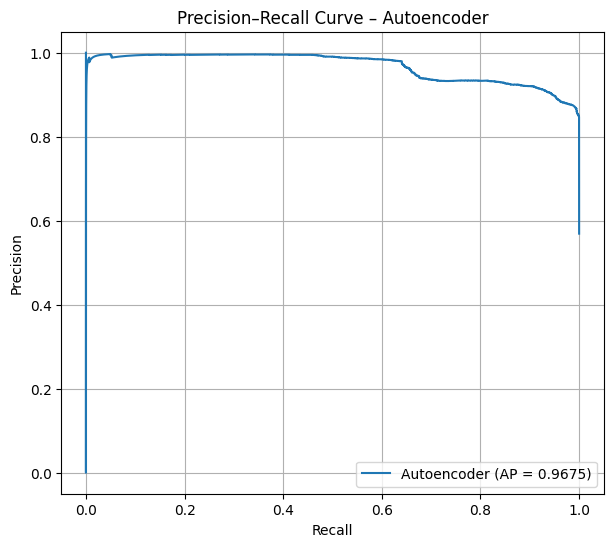

In [ ]:
# ROC CURVE & AUC

roc_auc = roc_auc_score(y_test, test_error)
fpr, tpr, _ = roc_curve(y_test, test_error)

print("\nROC-AUC (Autoencoder):", roc_auc)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Autoencoder (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Autoencoder")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# PRECISION–RECALL CURVE
# =========================================================

precision, recall, _ = precision_recall_curve(y_test, test_error)
avg_precision = average_precision_score(y_test, test_error)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"Autoencoder (AP = {avg_precision:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Autoencoder")
plt.legend()
plt.grid(True)
plt.show()

In [74]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)

In [ ]:
# RECONSTRUCTION ERROR ON TRAIN (NORMAL-ONLY)
train_pred = best_model.predict(X_train_proc)
train_error = np.mean(
    np.square(X_train_proc - train_pred),
    axis=1
)

2105/2105 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [ ]:
# LF THRESHOLD (NORMAL-ONLY TRAIN)
lf_percentile = 98  # 2% false alarm rate
lf_threshold = np.percentile(train_error, lf_percentile)

print(f"LF Threshold ({lf_percentile}th percentile):", lf_threshold)

LF Threshold (98th percentile): 0.014898584864645112


In [ ]:
# RECONSTRUCTION ERROR ON TEST
test_pred = best_model.predict(X_test_proc)
test_error = np.mean(
    np.square(X_test_proc - test_pred),
    axis=1
)

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [78]:
# Binary predictions
# 1 = Attack (anomaly), 0 = Normal
y_pred_lf = (test_error > lf_threshold).astype(int)

In [ ]:
# CLASSIFICATION REPORT
print("\n=== Classification Report (LF Threshold) ===\n")
print(classification_report(
    y_test,
    y_pred_lf,
    target_names=["Normal", "Attack"]
))


=== Classification Report (LF Threshold) ===

              precision    recall  f1-score   support

      Normal       0.81      0.91      0.86      9711
      Attack       0.93      0.84      0.88     12833

    accuracy                           0.87     22544
   macro avg       0.87      0.88      0.87     22544
weighted avg       0.88      0.87      0.87     22544



,Pred Normal,Pred Attack
Actual Normal,8848,863
Actual Attack,2017,10816


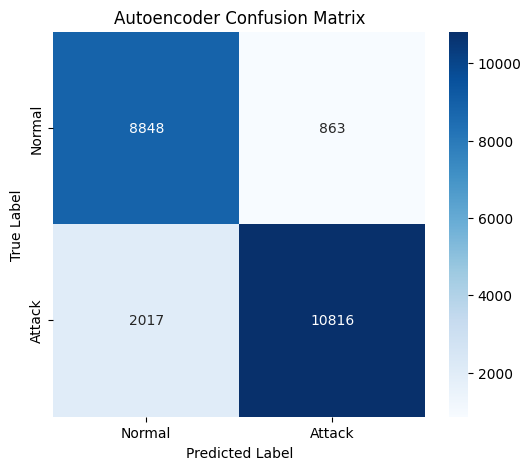

In [ ]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_lf)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Normal", "Actual Attack"],
    columns=["Pred Normal", "Pred Attack"]
)

display(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Autoencoder Confusion Matrix")
plt.show()



ROC–AUC (Autoencoder): 0.9606258002697339


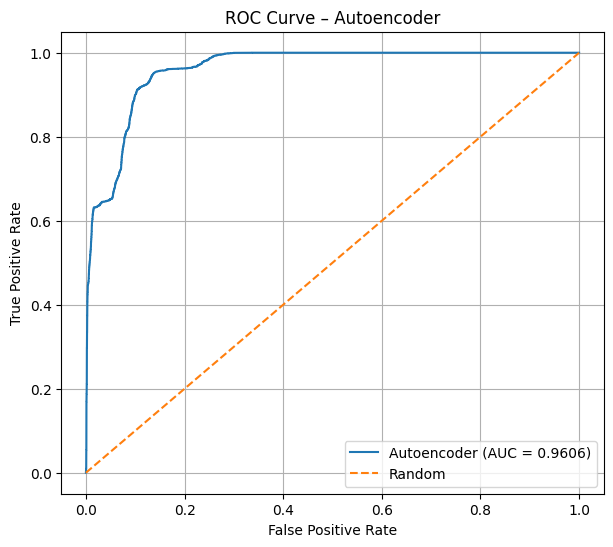

In [ ]:
# ROC CURVE & AUC (USING RAW RECONSTRUCTION ERROR)
roc_auc = roc_auc_score(y_test, test_error)
fpr, tpr, _ = roc_curve(y_test, test_error)

print("ROC-AUC (Autoencoder):", roc_auc)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Autoencoder (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Autoencoder")
plt.legend()
plt.grid(True)
plt.show()

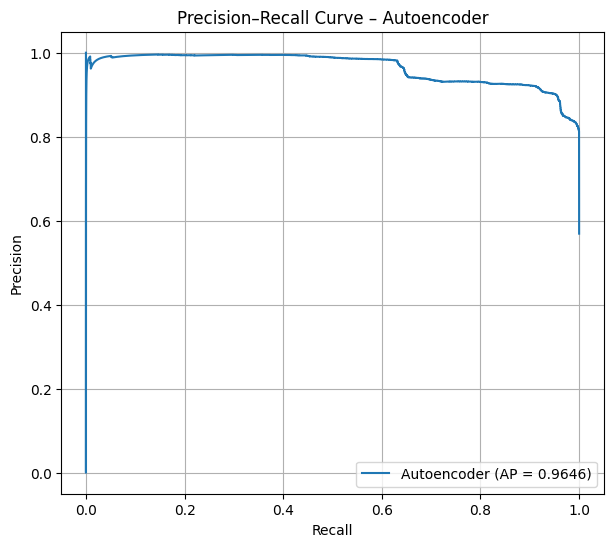

In [ ]:
# PRECISION–RECALL CURVE
precision, recall, _ = precision_recall_curve(y_test, test_error)
avg_precision = average_precision_score(y_test, test_error)

plt.figure(figsize=(7, 6))
plt.plot(
    recall,
    precision,
    label=f"Autoencoder (AP = {avg_precision:.4f})"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Autoencoder")
plt.legend()
plt.grid(True)
plt.show()